# Preprocessing & EDA
## Healthcare Sector Focus

**Goal**: Analyse the UK ICO data security incident trends with a focus on the healthcare sector to prepare for building ML models and a dashboard.

**Issues to address**: 
- Multiple rows assigned to one power BI reference (same incident, multiple characteristics).
- Definition change in april 2021 for "informal action" and "no further action".
- Unknown/ unassigned values.
- Categorical data needs encoding

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the dataset
df_original = pd.read_csv("data-security-incidents-trends-q1-2019-to-q2-2025.csv", delimiter = ",")

# inital look at data
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188251 entries, 0 to 188250
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   BI Reference                188251 non-null  object
 1   Year                        188251 non-null  int64 
 2   Quarter                     188251 non-null  object
 3   Data Subject Type           188251 non-null  object
 4   Data Type                   188251 non-null  object
 5   Decision Taken              188251 non-null  object
 6   Incident Category           188251 non-null  object
 7   Incident Type               188251 non-null  object
 8   No. Data Subjects Affected  188251 non-null  object
 9   Sector                      188251 non-null  object
 10  Time Taken to Report        188251 non-null  object
dtypes: int64(1), object(10)
memory usage: 15.8+ MB



Total sectors: 23


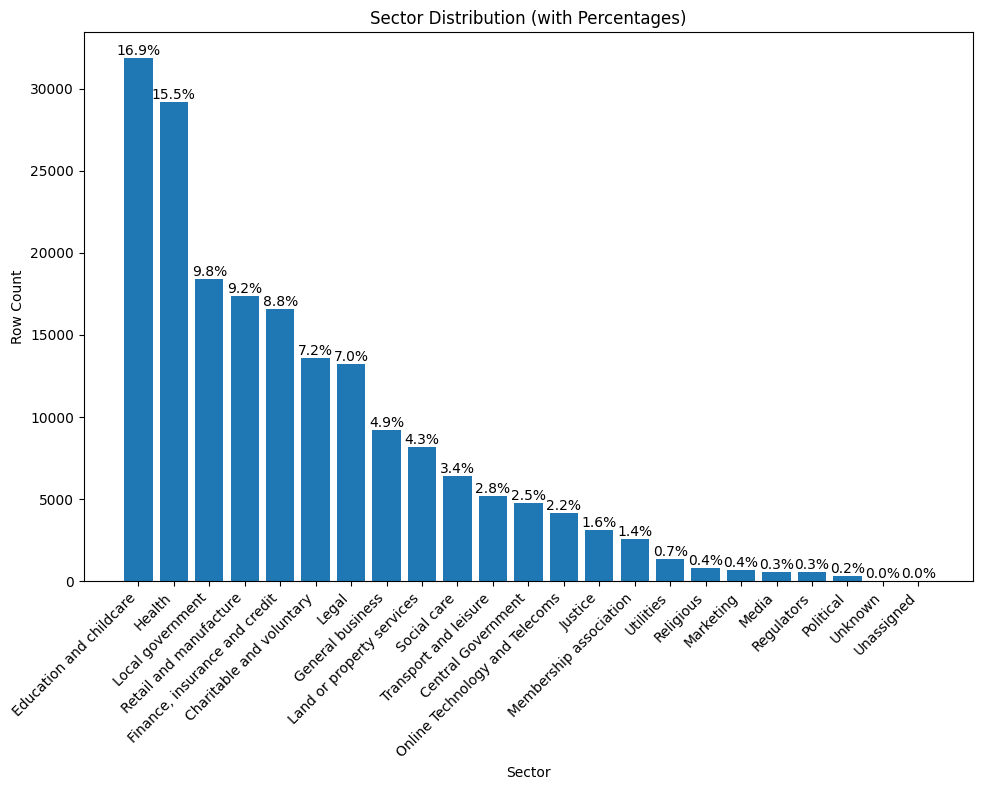

In [3]:
# count all sectors
sector_counts = df_original['Sector'].value_counts()
sector_perc = sector_counts / len(df_original) * 100

plt.figure(figsize=(10, 8))
bars = plt.bar(sector_counts.index, sector_counts.values)

plt.title("Sector Distribution (with Percentages)")
plt.xlabel("Sector")
plt.ylabel("Row Count")
plt.xticks(rotation=45, ha='right')

# add percentage labels on top of each bar
for bar, pct in zip(bars, sector_perc):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, # put percentage in the middle
        height, f"{pct:.1f}%",
        ha='center', va='bottom'
    )

print(f"\nTotal sectors: {df_original['Sector'].nunique()}")

plt.tight_layout()
plt.show()

In [4]:
# filtering the database to focus of the health sector
df_health = df_original[df_original["Sector"] == "Health"].copy(deep=True)

# standardising the column names
df_health.columns = df_health.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(".", "")

# look at new healthcare sector focused df
df_health.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29198 entries, 12 to 188238
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   bi_reference               29198 non-null  object
 1   year                       29198 non-null  int64 
 2   quarter                    29198 non-null  object
 3   data_subject_type          29198 non-null  object
 4   data_type                  29198 non-null  object
 5   decision_taken             29198 non-null  object
 6   incident_category          29198 non-null  object
 7   incident_type              29198 non-null  object
 8   no_data_subjects_affected  29198 non-null  object
 9   sector                     29198 non-null  object
 10  time_taken_to_report       29198 non-null  object
dtypes: int64(1), object(10)
memory usage: 2.7+ MB


In [5]:
# change data type of features into categorical instead of object/ int as characteristics are fixed
categorical_cols = [
    "bi_reference",
    "year",
    "quarter",
    "data_subject_type",
    "data_type",
    "decision_taken",
    "incident_category",
    "incident_type",
    "no_data_subjects_affected",
    "sector",
    "time_taken_to_report"
]

for col in categorical_cols:
    df_health[col] = df_health[col].astype("category")

# verify new data types
df_health.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29198 entries, 12 to 188238
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               29198 non-null  category
 1   year                       29198 non-null  category
 2   quarter                    29198 non-null  category
 3   data_subject_type          29198 non-null  category
 4   data_type                  29198 non-null  category
 5   decision_taken             29198 non-null  category
 6   incident_category          29198 non-null  category
 7   incident_type              29198 non-null  category
 8   no_data_subjects_affected  29198 non-null  category
 9   sector                     29198 non-null  category
 10  time_taken_to_report       29198 non-null  category
dtypes: category(11)
memory usage: 1.2 MB


In [6]:
# finding the unique vs total BI references 
total_rows = len(df_health)-1 # -1 for column header
unique_bi_refs = df_health['bi_reference'].nunique()
duplicate_ratio = (total_rows - unique_bi_refs) / total_rows * 100

print(f"\nTotal rows in the dataset: {total_rows:,}")
print(f"Unique BI References: {unique_bi_refs:,}")
print(f"Rows representing duplicate characteristics: {total_rows - unique_bi_refs:,}")
print(f"Duplication rate: {duplicate_ratio:.2f}%")


Total rows in the dataset: 29,197
Unique BI References: 13,011
Rows representing duplicate characteristics: 16,186
Duplication rate: 55.44%


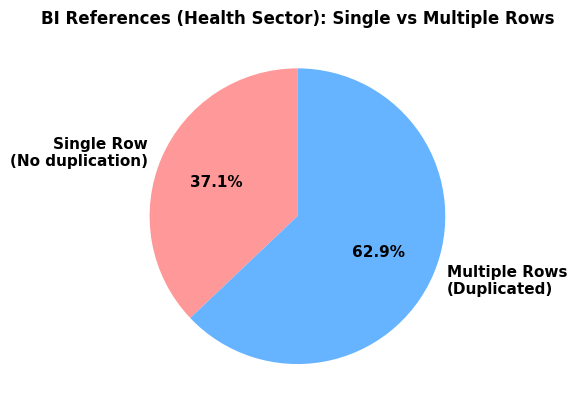

In [7]:
# plot: pie chart of unique vs duplicate references
bi_ref_counts = df_health['bi_reference'].value_counts()
single_row = (bi_ref_counts == 1).sum()
multiple_rows = (bi_ref_counts > 1).sum()
plt.pie([single_row, multiple_rows], 
            labels=['Single Row\n(No duplication)', 'Multiple Rows\n(Duplicated)'], 
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
plt.title('BI References (Health Sector): Single vs Multiple Rows', fontsize=12, fontweight='bold')
plt.show()

In [8]:
# analyse which columns typically vary across duplicates
duplicated_bi_refs = df_health[df_health['bi_reference'].duplicated(keep=False)] # slice

# nunique per group per column
varying_columns = duplicated_bi_refs.groupby("bi_reference", observed=False).nunique()

# a column varies in a group if nunique > 1
varying_counts = (varying_columns > 1).sum()

total_groups = duplicated_bi_refs['bi_reference'].nunique()
result = (varying_counts
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

result["percentage"] = (result["count"] / total_groups * 100)
print(f"Columns that vary across duplicate rows:\n {result}")

# summarise how many characteristics each breach has
print("\nBreach characteristics per incident:")
df_health.groupby("bi_reference", observed=False).size().describe()

Columns that vary across duplicate rows:
                            count  percentage
data_type                   7521   91.887599
data_subject_type           2038   24.899206
quarter                        0    0.000000
year                           0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
no_data_subjects_affected      0    0.000000
sector                         0    0.000000
time_taken_to_report           0    0.000000

Breach characteristics per incident:


count    13011.000000
mean         2.244101
std          2.663049
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         66.000000
dtype: float64

Missing values in the healthcare dataset:
bi_reference                 0
year                         0
quarter                      0
data_subject_type            0
data_type                    0
decision_taken               0
incident_category            0
incident_type                0
no_data_subjects_affected    0
sector                       0
time_taken_to_report         0
dtype: int64


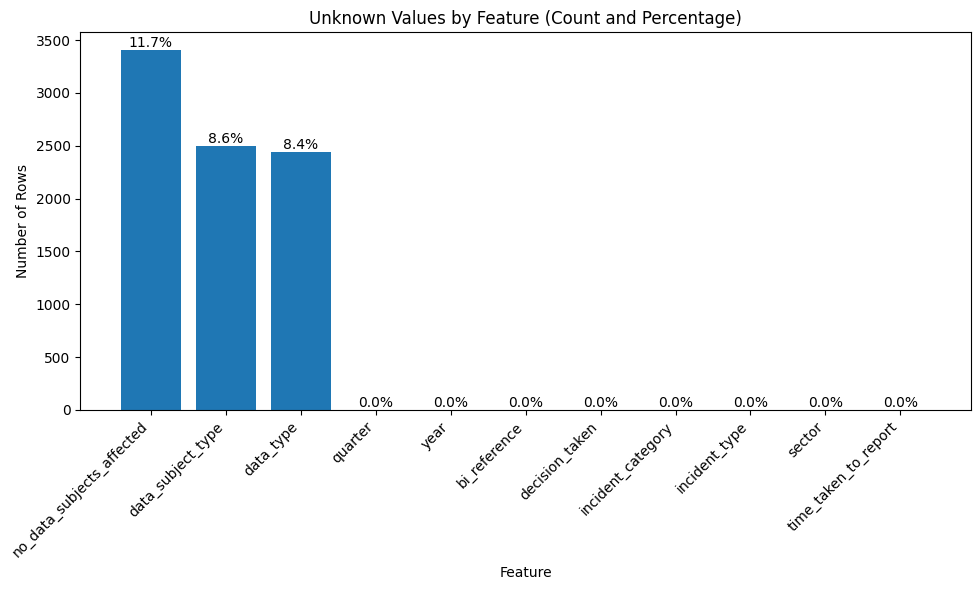

Unknown characteristic counts in each feature:
no_data_subjects_affected    3403
data_subject_type            2497
data_type                    2442
quarter                         0
year                            0
bi_reference                    0
decision_taken                  0
incident_category               0
incident_type                   0
sector                          0
time_taken_to_report            0
dtype: int64


In [9]:
# checking how many missing/ unknown values are in the healthcare df
print(f"Missing values in the healthcare dataset:\n{df_health.isnull().sum()}")

unknown_counts = df_health[categorical_cols].isin(["Unknown"]).sum().sort_values(ascending=False)

# calculate percentages
unknown_perc = (unknown_counts / len(df_health)) * 100

# visualise per feature
plt.figure(figsize=(10, 6))
bars = plt.bar(unknown_counts.index, unknown_counts.values)

plt.title("Unknown Values by Feature (Count and Percentage)")
plt.xlabel("Feature")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45, ha="right")

# add percentage labels
for bar, pct in zip(bars, unknown_perc):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height, f"{pct:.1f}%",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()
print(f"Unknown characteristic counts in each feature:\n{unknown_counts}")

Healthcare Data Security Incidents Over Time:
Year Quarter  Total Rows  Unique Incidents  Duplicates  Duplicate %
2019   Qtr 1        1135               527         608         53.6
2019   Qtr 2        1035               485         550         53.1
2019   Qtr 3        1351               598         753         55.7
2019   Qtr 4        1176               546         630         53.6
2020   Qtr 1         961               423         538         56.0
2020   Qtr 2         783               362         421         53.8
2020   Qtr 3         927               429         498         53.7
2020   Qtr 4        1031               428         603         58.5
2021   Qtr 1         849               412         437         51.5
2021   Qtr 2        1286               603         683         53.1
2021   Qtr 3         915               432         483         52.8
2021   Qtr 4         991               461         530         53.5
2022   Qtr 1         913               421         492         53.9
20

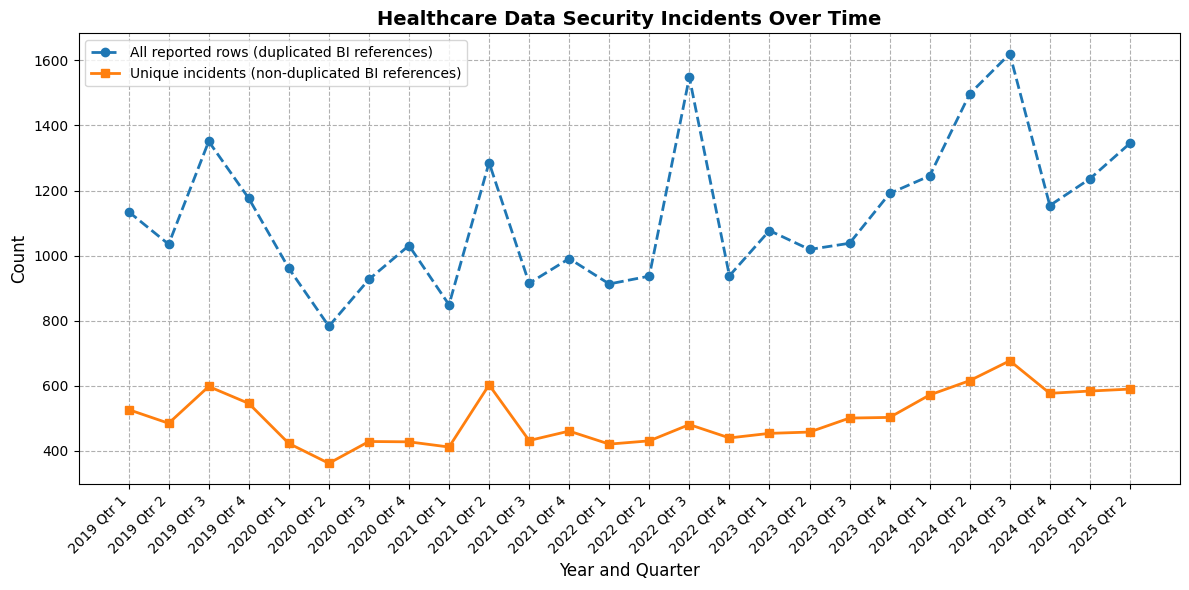

In [40]:
# aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health
    .groupby(["year", "quarter"], observed=True) 
    .size()
    .reset_index(name="total_incidents")
)

# aggregate unique incidents per year-quarter (non-duplicated BI references)
unique_incidents = (
    df_health
    .groupby(["year", "quarter"], observed=True)  
    ["bi_reference"]
    .nunique()
    .reset_index(name="unique_incidents")
)

# merge the two summaries
incidents_over_time = total_incidents.merge(
    unique_incidents,
    on=["year", "quarter"]
)

# make the chronological order
quarter_order = {"Qtr1": 1, "Qtr2": 2, "Qtr3": 3, "Qtr4": 4}
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarter_order)

# convert year to int for sorting
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)

incidents_over_time = incidents_over_time.sort_values(
    by=["year_num", "quarter_num"]
).reset_index(drop=True)

# x-axis label
incidents_over_time["period"] = (
    incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str)
)

# copy for display purposes
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
# calculate the difference (duplicate count) & percentage of duplicates
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
display_df["duplicate_pct"] = (display_df["duplicates"] / display_df["total_incidents"] * 100).round(1)
# display columns
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates", "Duplicate %"]

# tabular form
print("Healthcare Data Security Incidents Over Time:")
print(display_df.to_string(index=False))

# summary statistics
print(f"\nOverall Summary:")
print(f"\tTotal Rows Across All Periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal Unique Incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal Duplicates: {display_df['Duplicates'].sum():,}")
print(f"\tAverage Duplicate Rate: {display_df['Duplicate %'].mean():.1f}%")


# graph visualisation of incidents 
plt.figure(figsize=(12, 6))

plt.plot(
    incidents_over_time.index,
    incidents_over_time["total_incidents"],
    marker='o',
    label="All reported rows (duplicated BI references)",
    linestyle="--",
    linewidth=2,
    markersize=6
)

plt.plot(
    incidents_over_time.index,
    incidents_over_time["unique_incidents"],
    marker='s',
    label="Unique incidents (non-duplicated BI references)",
    linewidth=2,
    markersize=6
)

plt.xticks(
    ticks=incidents_over_time.index,
    labels=incidents_over_time["period"],
    rotation=45, ha='right'
)

plt.title("Healthcare Data Security Incidents Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()